# 03 — Feature Engineering

**Goal:** Compute all features for every match in `matches_clean.csv`, assemble the final feature matrix for model training.

**Features to compute:**
1. **ELO ratings** — per team, updated after every match chronologically
2. **Recent form** — last 5 and 10 matches (win rate, goals scored/conceded, points per match)
3. **Head-to-head** — historical record for each specific team pair
4. **Static features** — neutral ground flag, confederation, tournament category

**Critical rule:** All features must be computed using only data available *before* the match being predicted. No data leakage.

**Input:** `data/processed/matches_clean.csv`  
**Output:** `data/processed/features_matrix.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

sns.set_theme(style="darkgrid")
PROCESSED_DIR = Path("../data/processed")

print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load Clean Data

In [2]:
df = pd.read_csv(PROCESSED_DIR / "matches_clean.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Loaded: {len(df):,} matches")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")

Loaded: 60,692 matches
Date range: 1872-11-30 to 2026-03-31
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'source', 'tournament_category', 'elo_k', 'home_confederation', 'away_confederation', 'outcome', 'goal_diff']


## Step 2 — ELO Rating Computation

ELO is computed by iterating through ALL matches chronologically from 1872.
For each match we record each team's ELO **before** the match (no leakage), then update.

**Formula:** `Rn = Ro + K * goal_multiplier * (W - We)`
- `We = 1 / (1 + 10^(-dr/400))` where `dr = elo_diff + home_advantage`
- Home advantage: +100 ELO points when `neutral=False`
- K from `elo_k` column (60=WC, 50=continental, 40=qualifier, 30=other, 20=friendly)
- Goal difference multiplier on K: 1.0 (1 goal), 1.5 (2 goals), 1.75 (3 goals), 1.75+(N-3)/8 (4+)

In [3]:
def goal_diff_multiplier(gd):
    """K multiplier based on goal difference (absolute value)."""
    gd = abs(gd)
    if gd <= 1:
        return 1.0
    elif gd == 2:
        return 1.5
    elif gd == 3:
        return 1.75
    else:
        return 1.75 + (gd - 3) / 8

def compute_elo(df, initial_rating=1500, home_advantage=100):
    """
    Compute ELO ratings for all teams across all matches.
    Returns:
        - df with home_elo_before, away_elo_before columns added
        - final_elos dict: {team: final_elo}
    """
    elos = defaultdict(lambda: initial_rating)
    
    home_elos_before = []
    away_elos_before = []
    
    for _, row in df.iterrows():
        home = row['home_team']
        away = row['away_team']
        home_score = row['home_score']
        away_score = row['away_score']
        K = row['elo_k']
        neutral = row['neutral']
        gd = home_score - away_score
        
        # Snapshot BEFORE the match
        home_elo = elos[home]
        away_elo = elos[away]
        home_elos_before.append(home_elo)
        away_elos_before.append(away_elo)
        
        # Home advantage only applies on non-neutral ground
        ha = 0 if neutral else home_advantage
        dr = home_elo - away_elo + ha
        
        # Expected result for home team
        We_home = 1 / (1 + 10 ** (-dr / 400))
        We_away = 1 - We_home
        
        # Actual result
        if gd > 0:
            W_home, W_away = 1.0, 0.0
        elif gd < 0:
            W_home, W_away = 0.0, 1.0
        else:
            W_home, W_away = 0.5, 0.5
        
        # Update ratings
        gdm = goal_diff_multiplier(gd)
        elos[home] = home_elo + K * gdm * (W_home - We_home)
        elos[away] = away_elo + K * gdm * (W_away - We_away)
    
    df = df.copy()
    df['home_elo_before'] = home_elos_before
    df['away_elo_before'] = away_elos_before
    df['elo_diff'] = df['home_elo_before'] - df['away_elo_before']
    
    return df, dict(elos)

print("ELO functions defined.")
print("Testing goal_diff_multiplier:")
for gd in [0, 1, 2, 3, 4, 5, 7]:
    print(f"  gd={gd} -> multiplier={goal_diff_multiplier(gd):.3f}")

ELO functions defined.
Testing goal_diff_multiplier:
  gd=0 -> multiplier=1.000
  gd=1 -> multiplier=1.000
  gd=2 -> multiplier=1.500
  gd=3 -> multiplier=1.750
  gd=4 -> multiplier=1.875
  gd=5 -> multiplier=2.000
  gd=7 -> multiplier=2.250


In [4]:
# Run ELO computation across all 60k+ matches
print("Computing ELO ratings...")
df, final_elos = compute_elo(df)

print(f"Done. ELO computed for {len(final_elos)} teams.")
print(f"\nTop 20 teams by final ELO:")
top_elos = sorted(final_elos.items(), key=lambda x: x[1], reverse=True)[:20]
for team, elo in top_elos:
    print(f"  {team:30s} {elo:.1f}")

print(f"\nBottom 10 teams by final ELO:")
bottom_elos = sorted(final_elos.items(), key=lambda x: x[1])[:10]
for team, elo in bottom_elos:
    print(f"  {team:30s} {elo:.1f}")

Computing ELO ratings...
Done. ELO computed for 342 teams.

Top 20 teams by final ELO:
  Spain                          2269.6
  Argentina                      2226.9
  France                         2210.9
  England                        2148.6
  Colombia                       2096.0
  Brazil                         2085.9
  Portugal                       2054.0
  Netherlands                    2043.8
  Japan                          2041.4
  Germany                        2033.6
  Ecuador                        2032.1
  Croatia                        2029.1
  Norway                         2023.0
  Uruguay                        2015.2
  Turkey                         2015.1
  Switzerland                    2006.9
  Morocco                        1989.1
  Mexico                         1987.3
  Denmark                        1984.9
  Senegal                        1981.5

Bottom 10 teams by final ELO:
  Northern Mariana Islands       759.5
  American Samoa                 809.2
  Ma

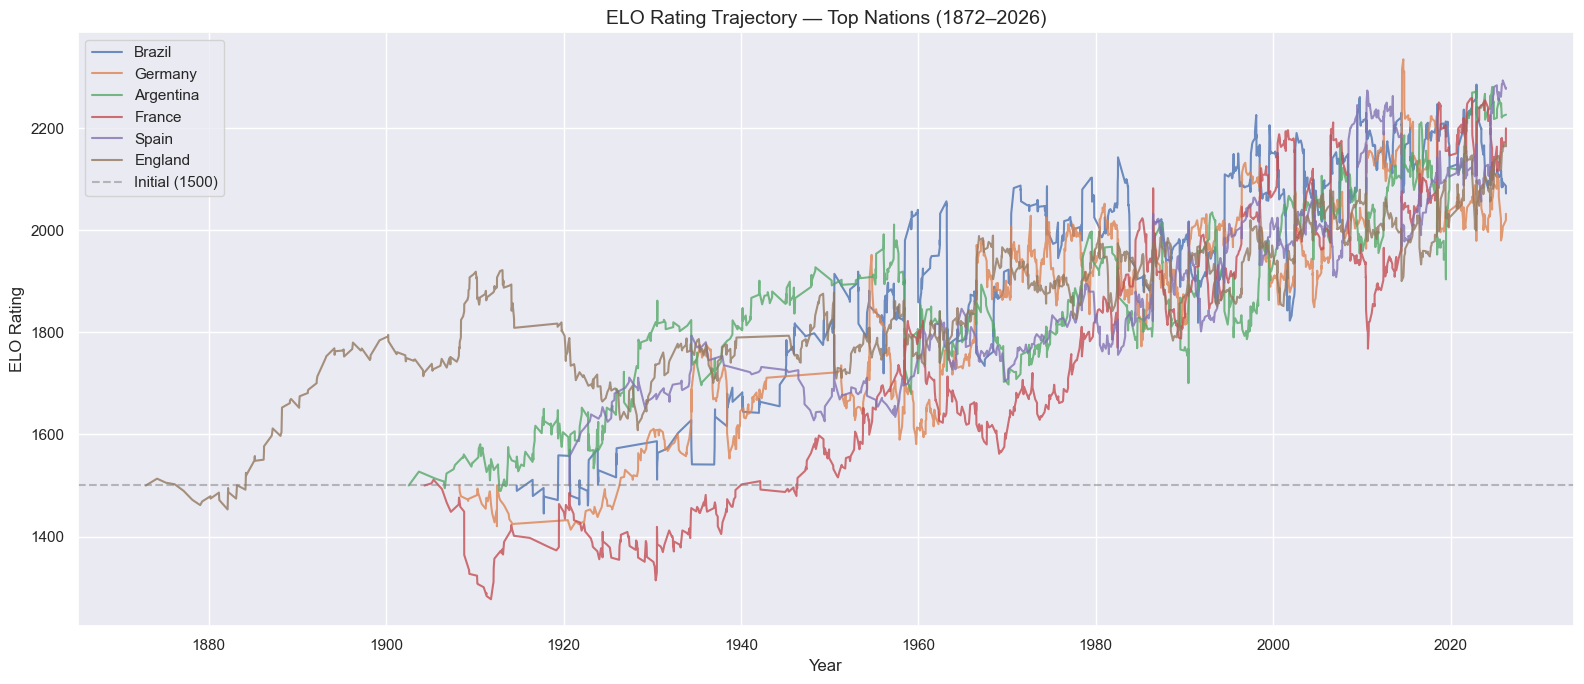

In [5]:
# ELO sanity check — plot ELO trajectory of a few well-known teams
teams_to_plot = ['Brazil', 'Germany', 'Argentina', 'France', 'Spain', 'England']

fig, ax = plt.subplots(figsize=(16, 7))

for team in teams_to_plot:
    mask = (df['home_team'] == team) | (df['away_team'] == team)
    team_df = df[mask].copy()
    team_df['team_elo'] = team_df.apply(
        lambda r: r['home_elo_before'] if r['home_team'] == team else r['away_elo_before'], axis=1
    )
    ax.plot(team_df['date'], team_df['team_elo'], label=team, alpha=0.8, linewidth=1.5)

ax.axhline(1500, color='gray', linestyle='--', alpha=0.5, label='Initial (1500)')
ax.set_title('ELO Rating Trajectory — Top Nations (1872–2026)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('ELO Rating')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
# Save final ELO ratings (used later for 2026 predictions)
elo_df = pd.DataFrame([
    {'team': team, 'final_elo': round(elo, 2)}
    for team, elo in sorted(final_elos.items(), key=lambda x: x[1], reverse=True)
])
elo_df.to_csv(PROCESSED_DIR / 'final_elos.csv', index=False)
print(f"Saved final_elos.csv — {len(elo_df)} teams")
print(f"\nELO range: {elo_df['final_elo'].min():.1f} to {elo_df['final_elo'].max():.1f}")
print(f"Mean ELO: {elo_df['final_elo'].mean():.1f} (should be ~1500)")

Saved final_elos.csv — 342 teams

ELO range: 759.5 to 2269.6
Mean ELO: 1500.1 (should be ~1500)


## Step 3 — Recent Form Features

For each team at each match, compute over their last N matches (N=5 and N=10):
- Win rate
- Average goals scored
- Average goals conceded
- Points per match (W=3, D=1, L=0)

We exclude friendlies from form calculations (they're low-stakes and don't reflect competitive form).
If a team has fewer than N previous matches, we use whatever is available (no NaN).

In [7]:
def compute_form_features(df, windows=[5, 10], exclude_friendly=True):
    """
    For each match, compute form features for both home and away team
    using their last N matches BEFORE the current match.
    """
    # Build per-team match history as we go
    team_history = defaultdict(list)  # team -> list of (date, goals_scored, goals_conceded, result)
    
    results = []
    
    for idx, row in df.iterrows():
        home = row['home_team']
        away = row['away_team']
        is_friendly = row['tournament_category'] == 'friendly'
        
        row_features = {}
        
        for team, prefix, goals_scored, goals_conceded, won, drew in [
            (home, 'home', row['home_score'], row['away_score'],
             row['home_score'] > row['away_score'], row['home_score'] == row['away_score']),
            (away, 'away', row['away_score'], row['home_score'],
             row['away_score'] > row['home_score'], row['home_score'] == row['away_score'])
        ]:
            history = team_history[team]
            
            # Filter by competitive only if requested
            if exclude_friendly:
                comp_history = [h for h in history if not h['friendly']]
            else:
                comp_history = history
            
            for N in windows:
                recent = comp_history[-N:] if len(comp_history) >= 1 else []
                n = len(recent)
                
                if n == 0:
                    win_rate = 0.5  # neutral prior
                    avg_scored = 1.0
                    avg_conceded = 1.0
                    pts_per_match = 1.0
                else:
                    wins = sum(1 for h in recent if h['result'] == 'W')
                    draws = sum(1 for h in recent if h['result'] == 'D')
                    win_rate = wins / n
                    avg_scored = sum(h['scored'] for h in recent) / n
                    avg_conceded = sum(h['conceded'] for h in recent) / n
                    pts_per_match = (wins * 3 + draws * 1) / n
                
                row_features[f'{prefix}_win_rate_{N}'] = win_rate
                row_features[f'{prefix}_avg_scored_{N}'] = avg_scored
                row_features[f'{prefix}_avg_conceded_{N}'] = avg_conceded
                row_features[f'{prefix}_pts_per_match_{N}'] = pts_per_match
                row_features[f'{prefix}_matches_played_{N}'] = n  # confidence weight
        
        results.append(row_features)
        
        # Update history AFTER recording features (no leakage)
        home_result = 'W' if row['home_score'] > row['away_score'] else ('D' if row['home_score'] == row['away_score'] else 'L')
        away_result = 'W' if row['away_score'] > row['home_score'] else ('D' if row['home_score'] == row['away_score'] else 'L')
        
        team_history[home].append({
            'scored': row['home_score'], 'conceded': row['away_score'],
            'result': home_result, 'friendly': is_friendly
        })
        team_history[away].append({
            'scored': row['away_score'], 'conceded': row['home_score'],
            'result': away_result, 'friendly': is_friendly
        })
    
    return pd.DataFrame(results, index=df.index)

print("Form function defined. Computing form features...")
form_df = compute_form_features(df, windows=[5, 10], exclude_friendly=True)
print(f"Done. Form features shape: {form_df.shape}")
print(f"\nForm feature columns:")
print(list(form_df.columns))

Form function defined. Computing form features...
Done. Form features shape: (60692, 20)

Form feature columns:
['home_win_rate_5', 'home_avg_scored_5', 'home_avg_conceded_5', 'home_pts_per_match_5', 'home_matches_played_5', 'home_win_rate_10', 'home_avg_scored_10', 'home_avg_conceded_10', 'home_pts_per_match_10', 'home_matches_played_10', 'away_win_rate_5', 'away_avg_scored_5', 'away_avg_conceded_5', 'away_pts_per_match_5', 'away_matches_played_5', 'away_win_rate_10', 'away_avg_scored_10', 'away_avg_conceded_10', 'away_pts_per_match_10', 'away_matches_played_10']


In [8]:
# Sanity check — form stats for a recent match
recent_matches = df[df['date'] >= '2022-01-01'].head(5)
print("Sample form features for recent matches:")
for idx in recent_matches.index:
    row = df.loc[idx]
    form = form_df.loc[idx]
    print(f"\n  {row['date'].date()} | {row['home_team']} vs {row['away_team']} | {row['home_score']}-{row['away_score']}")
    print(f"  Home form (last 5 competitive): win={form['home_win_rate_5']:.2f}, "
          f"scored={form['home_avg_scored_5']:.2f}, conceded={form['home_avg_conceded_5']:.2f}, "
          f"pts={form['home_pts_per_match_5']:.2f} (n={form['home_matches_played_5']:.0f})")
    print(f"  Away form (last 5 competitive): win={form['away_win_rate_5']:.2f}, "
          f"scored={form['away_avg_scored_5']:.2f}, conceded={form['away_avg_conceded_5']:.2f}, "
          f"pts={form['away_pts_per_match_5']:.2f} (n={form['away_matches_played_5']:.0f})")

Sample form features for recent matches:

  2022-01-01 | Indonesia vs Thailand | 2-2
  Home form (last 5 competitive): win=0.40, scored=1.80, conceded=2.40, pts=1.40 (n=5)
  Away form (last 5 competitive): win=0.80, scored=2.40, conceded=0.00, pts=2.60 (n=5)

  2022-01-01 | Thailand vs Indonesia | 2-2
  Home form (last 5 competitive): win=0.60, scored=2.40, conceded=0.40, pts=2.20 (n=5)
  Away form (last 5 competitive): win=0.20, scored=1.40, conceded=2.60, pts=1.00 (n=5)

  2022-01-02 | Sudan vs Zimbabwe | 0-0
  Home form (last 5 competitive): win=0.00, scored=0.00, conceded=3.00, pts=0.20 (n=5)
  Away form (last 5 competitive): win=0.00, scored=0.40, conceded=1.40, pts=0.20 (n=5)

  2022-01-02 | Gabon vs Burkina Faso | 0-3
  Home form (last 5 competitive): win=0.40, scored=1.20, conceded=1.20, pts=1.40 (n=5)
  Away form (last 5 competitive): win=0.60, scored=2.60, conceded=0.60, pts=2.20 (n=5)

  2022-01-02 | Burkina Faso vs Gabon | 3-0
  Home form (last 5 competitive): win=0.60, sco

## Step 4 — Head-to-Head Features

For each matchup, compute historical record between the two specific teams:
- Home team win rate in H2H
- Average goals scored by home team in H2H
- Number of previous meetings (confidence weight)

Note: H2H is directional — we track `(team_a, team_b)` as a pair regardless of who was home.

In [9]:
def compute_h2h_features(df):
    """
    For each match, compute head-to-head stats between the two teams
    using only previous meetings.
    """
    # h2h_history[(teamA, teamB)] = list of past results from teamA's perspective
    h2h_history = defaultdict(list)
    
    results = []
    
    for _, row in df.iterrows():
        home = row['home_team']
        away = row['away_team']
        
        # Get H2H history (combine both directions)
        h2h = h2h_history[(home, away)] + [
            {'scored': h['conceded'], 'conceded': h['scored'], 'result': {'W':'L','L':'W','D':'D'}[h['result']]}
            for h in h2h_history[(away, home)]
        ]
        
        n = len(h2h)
        recent_h2h = h2h[-5:]  # last 5 meetings
        n_recent = len(recent_h2h)
        
        if n == 0:
            h2h_home_win_rate = 0.5
            h2h_home_avg_scored = 1.0
            h2h_home_avg_conceded = 1.0
        else:
            wins = sum(1 for h in h2h if h['result'] == 'W')
            h2h_home_win_rate = wins / n
            h2h_home_avg_scored = sum(h['scored'] for h in h2h) / n
            h2h_home_avg_conceded = sum(h['conceded'] for h in h2h) / n
        
        if n_recent == 0:
            h2h_recent_win_rate = 0.5
        else:
            recent_wins = sum(1 for h in recent_h2h if h['result'] == 'W')
            h2h_recent_win_rate = recent_wins / n_recent
        
        results.append({
            'h2h_home_win_rate': h2h_home_win_rate,
            'h2h_home_avg_scored': h2h_home_avg_scored,
            'h2h_home_avg_conceded': h2h_home_avg_conceded,
            'h2h_total_meetings': n,
            'h2h_recent_win_rate': h2h_recent_win_rate,
        })
        
        # Update H2H history AFTER recording (no leakage)
        home_result = 'W' if row['home_score'] > row['away_score'] else ('D' if row['home_score'] == row['away_score'] else 'L')
        h2h_history[(home, away)].append({
            'scored': row['home_score'], 'conceded': row['away_score'], 'result': home_result
        })
    
    return pd.DataFrame(results, index=df.index)

print("Computing H2H features...")
h2h_df = compute_h2h_features(df)
print(f"Done. H2H features shape: {h2h_df.shape}")
print(f"\nH2H meetings distribution:")
print(h2h_df['h2h_total_meetings'].describe())

Computing H2H features...
Done. H2H features shape: (60692, 5)

H2H meetings distribution:
count    60692.000000
mean        13.578742
std         19.791779
min          0.000000
25%          2.000000
50%          6.000000
75%         17.000000
max        223.000000
Name: h2h_total_meetings, dtype: float64


In [10]:
# Sanity check — Brazil vs Argentina H2H
bra_arg = df[
    ((df['home_team'] == 'Brazil') & (df['away_team'] == 'Argentina')) |
    ((df['home_team'] == 'Argentina') & (df['away_team'] == 'Brazil'))
]
print(f"Brazil vs Argentina total meetings in dataset: {len(bra_arg)}")
print(f"\nLast 5 meetings:")
print(bra_arg[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']].tail(5).to_string(index=False))

# Check H2H features for their most recent match
last_idx = bra_arg.index[-1]
print(f"\nH2H features going into their most recent match:")
print(h2h_df.loc[last_idx])

Brazil vs Argentina total meetings in dataset: 124

Last 5 meetings:
      date home_team away_team  home_score  away_score                   tournament
2019-11-15 Argentina    Brazil           1           0                     Friendly
2021-07-10    Brazil Argentina           0           1                 Copa América
2021-11-16 Argentina    Brazil           0           0 FIFA World Cup qualification
2023-11-21    Brazil Argentina           0           1 FIFA World Cup qualification
2025-03-25 Argentina    Brazil           4           1 FIFA World Cup qualification

H2H features going into their most recent match:
h2h_home_win_rate          0.365854
h2h_home_avg_scored        1.430894
h2h_home_avg_conceded      1.512195
h2h_total_meetings       123.000000
h2h_recent_win_rate        0.600000
Name: 59424, dtype: float64


## Step 5 — Encode Static Features

Encode categorical features:
- `neutral` — already boolean, convert to int (0/1)
- `tournament_category` — ordinal encode (friendly=0, other=1, qualifier=2, continental=3, wc=4)
- `confederation` — one-hot encode (UEFA, CAF, AFC, CONCACAF, CONMEBOL, OFC, UNKNOWN)

In [11]:
# Tournament category ordinal encoding
TOURNAMENT_ORDINAL = {
    'friendly': 0,
    'other_competitive': 1,
    'qualifier': 2,
    'continental_final': 3,
    'world_cup': 4
}

# Confederation one-hot encoding
CONFEDERATIONS = ['UEFA', 'CAF', 'AFC', 'CONCACAF', 'CONMEBOL', 'OFC', 'UNKNOWN']

static_features = pd.DataFrame(index=df.index)

# Neutral ground
static_features['neutral'] = df['neutral'].astype(int)

# Tournament importance
static_features['tournament_importance'] = df['tournament_category'].map(TOURNAMENT_ORDINAL)

# Confederation one-hot (home)
for conf in CONFEDERATIONS:
    static_features[f'home_conf_{conf}'] = (df['home_confederation'] == conf).astype(int)

# Confederation one-hot (away)
for conf in CONFEDERATIONS:
    static_features[f'away_conf_{conf}'] = (df['away_confederation'] == conf).astype(int)

# Same confederation flag (derby-like effect)
static_features['same_confederation'] = (df['home_confederation'] == df['away_confederation']).astype(int)

print(f"Static features shape: {static_features.shape}")
print(f"Columns: {list(static_features.columns)}")

Static features shape: (60692, 17)
Columns: ['neutral', 'tournament_importance', 'home_conf_UEFA', 'home_conf_CAF', 'home_conf_AFC', 'home_conf_CONCACAF', 'home_conf_CONMEBOL', 'home_conf_OFC', 'home_conf_UNKNOWN', 'away_conf_UEFA', 'away_conf_CAF', 'away_conf_AFC', 'away_conf_CONCACAF', 'away_conf_CONMEBOL', 'away_conf_OFC', 'away_conf_UNKNOWN', 'same_confederation']


## Step 6 — Assemble Final Feature Matrix

In [12]:
# Combine all features with match metadata
meta_cols = ['date', 'home_team', 'away_team', 'home_score', 'away_score',
             'tournament', 'tournament_category', 'neutral', 'outcome', 'goal_diff']

feature_matrix = pd.concat([
    df[meta_cols].reset_index(drop=True),
    df[['home_elo_before', 'away_elo_before', 'elo_diff']].reset_index(drop=True),
    form_df.reset_index(drop=True),
    h2h_df.reset_index(drop=True),
    static_features.reset_index(drop=True),
], axis=1)

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Total features: {feature_matrix.shape[1] - len(meta_cols)}")
print(f"\nAll columns:")
for col in feature_matrix.columns:
    print(f"  {col}")

Feature matrix shape: (60692, 55)
Total features: 45

All columns:
  date
  home_team
  away_team
  home_score
  away_score
  tournament
  tournament_category
  neutral
  outcome
  goal_diff
  home_elo_before
  away_elo_before
  elo_diff
  home_win_rate_5
  home_avg_scored_5
  home_avg_conceded_5
  home_pts_per_match_5
  home_matches_played_5
  home_win_rate_10
  home_avg_scored_10
  home_avg_conceded_10
  home_pts_per_match_10
  home_matches_played_10
  away_win_rate_5
  away_avg_scored_5
  away_avg_conceded_5
  away_pts_per_match_5
  away_matches_played_5
  away_win_rate_10
  away_avg_scored_10
  away_avg_conceded_10
  away_pts_per_match_10
  away_matches_played_10
  h2h_home_win_rate
  h2h_home_avg_scored
  h2h_home_avg_conceded
  h2h_total_meetings
  h2h_recent_win_rate
  neutral
  tournament_importance
  home_conf_UEFA
  home_conf_CAF
  home_conf_AFC
  home_conf_CONCACAF
  home_conf_CONMEBOL
  home_conf_OFC
  home_conf_UNKNOWN
  away_conf_UEFA
  away_conf_CAF
  away_conf_AFC
  awa

In [13]:
# Check for any nulls in feature columns
feature_cols = [c for c in feature_matrix.columns if c not in meta_cols]
null_check = feature_matrix[feature_cols].isnull().sum()
print("Null values in features:")
print(null_check[null_check > 0] if null_check.sum() > 0 else "None — all features complete.")

print(f"\nFeature statistics:")
print(feature_matrix[['home_elo_before', 'away_elo_before', 'elo_diff',
                       'home_win_rate_5', 'away_win_rate_5',
                       'h2h_home_win_rate', 'h2h_total_meetings']].describe().round(2))

Null values in features:
None — all features complete.

Feature statistics:
       home_elo_before  away_elo_before  elo_diff  home_win_rate_5  \
count         60692.00         60692.00  60692.00         60692.00   
mean           1603.12          1585.00     18.12             0.40   
std             228.69           234.79    240.12             0.27   
min             719.82           708.10  -1251.34             0.00   
25%            1456.38          1440.52   -130.82             0.20   
50%            1605.41          1591.68     16.88             0.40   
75%            1755.72          1744.51    166.37             0.60   
max            2335.00          2311.14   1255.16             1.00   

       away_win_rate_5  h2h_home_win_rate  h2h_total_meetings  
count         60692.00           60692.00            60692.00  
mean              0.39               0.42               13.58  
std               0.27               0.30               19.79  
min               0.00               

## Step 7 — Feature Correlation & Importance Preview

In [14]:
# Encode outcome as numeric for correlation
outcome_map = {'home_win': 1, 'draw': 0, 'away_win': -1}
feature_matrix['outcome_num'] = feature_matrix['outcome'].map(outcome_map)

# Correlation of key features with outcome
key_features = [
    'elo_diff', 'home_elo_before', 'away_elo_before',
    'home_win_rate_5', 'away_win_rate_5',
    'home_win_rate_10', 'away_win_rate_10',
    'home_pts_per_match_5', 'away_pts_per_match_5',
    'h2h_home_win_rate', 'h2h_total_meetings',
    'neutral', 'tournament_importance'
]
correlations = feature_matrix[key_features + ['outcome_num']].corr()['outcome_num'].drop('outcome_num').sort_values(ascending=False)

print("Feature correlation with outcome (home_win=1, draw=0, away_win=-1):")
for feat, corr in correlations.items():
    bar = '█' * int(abs(corr) * 40)
    sign = '+' if corr >= 0 else '-'
    print(f"  {feat:35s} {sign}{abs(corr):.3f} {bar}")

Feature correlation with outcome (home_win=1, draw=0, away_win=-1):
  elo_diff                            +0.476 ███████████████████
  h2h_home_win_rate                   +0.343 █████████████
  home_elo_before                     +0.227 █████████
  home_pts_per_match_5                +0.201 ████████
  home_win_rate_10                    +0.193 ███████
  home_win_rate_5                     +0.178 ███████
  neutral                             +0.055 ██
  neutral                             +0.055 ██
  tournament_importance               +0.019 
  h2h_total_meetings                  -0.011 
  away_win_rate_5                     -0.177 ███████
  away_win_rate_10                    -0.196 ███████
  away_pts_per_match_5                -0.197 ███████
  away_elo_before                     -0.266 ██████████


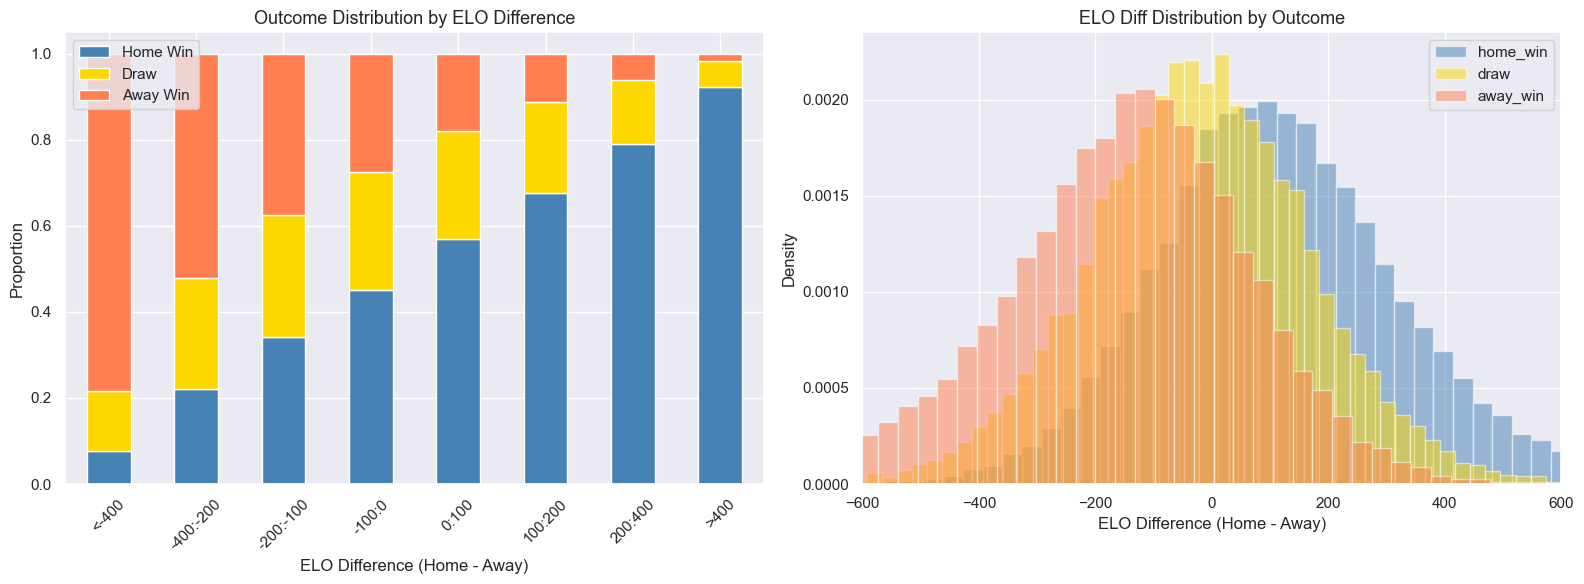

In [15]:
# ELO diff vs outcome — how predictive is ELO alone?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Win rate by ELO diff bucket
feature_matrix['elo_diff_bucket'] = pd.cut(feature_matrix['elo_diff'],
    bins=[-2000, -400, -200, -100, 0, 100, 200, 400, 2000],
    labels=['<-400', '-400:-200', '-200:-100', '-100:0', '0:100', '100:200', '200:400', '>400'])

win_by_bucket = feature_matrix.groupby('elo_diff_bucket', observed=True)['outcome'].value_counts(normalize=True).unstack(fill_value=0)
win_by_bucket[['home_win', 'draw', 'away_win']].plot(kind='bar', stacked=True, ax=axes[0],
    color=['steelblue', 'gold', 'coral'], edgecolor='white')
axes[0].set_title('Outcome Distribution by ELO Difference', fontsize=13)
axes[0].set_xlabel('ELO Difference (Home - Away)')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Home Win', 'Draw', 'Away Win'])

# ELO distribution by outcome
for outcome, color in [('home_win', 'steelblue'), ('draw', 'gold'), ('away_win', 'coral')]:
    subset = feature_matrix[feature_matrix['outcome'] == outcome]['elo_diff']
    axes[1].hist(subset, bins=60, alpha=0.5, color=color, label=outcome, density=True)
axes[1].set_title('ELO Diff Distribution by Outcome', fontsize=13)
axes[1].set_xlabel('ELO Difference (Home - Away)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_xlim(-600, 600)

plt.tight_layout()
plt.show()

## Step 8 — Train / Test Split

**Time-based split** — train on pre-2022 WC data, test on 2022 WC + matches after.
This simulates the real use case: train on history, predict a future tournament.
No random shuffling — chronological order must be preserved.

In [16]:
# Filter to competitive matches only for training
# (exclude friendlies — low signal, adds noise to model)
TRAIN_ON_FRIENDLY = False

if TRAIN_ON_FRIENDLY:
    model_data = feature_matrix.copy()
else:
    model_data = feature_matrix[feature_matrix['tournament_category'] != 'friendly'].copy()
    print(f"Excluding friendlies: {len(feature_matrix) - len(model_data):,} rows removed")

# Split: train = before 2022 WC start (Nov 21, 2022), test = 2022 WC onwards
SPLIT_DATE = '2022-11-20'

train = model_data[model_data['date'] < SPLIT_DATE].copy()
test = model_data[model_data['date'] >= SPLIT_DATE].copy()

print(f"\nTrain set: {len(train):,} matches ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test set:  {len(test):,} matches ({test['date'].min().date()} to {test['date'].max().date()})")
print(f"\nTest set breakdown:")
print(test['tournament_category'].value_counts())
print(f"\nOutcome distribution — Train:")
print(train['outcome'].value_counts(normalize=True).round(3))
print(f"\nOutcome distribution — Test:")
print(test['outcome'].value_counts(normalize=True).round(3))

Excluding friendlies: 22,075 rows removed

Train set: 35,304 matches (1884-01-26 to 2022-11-19)
Test set:  3,313 matches (2022-11-20 to 2026-03-31)

Test set breakdown:
qualifier            1712
continental_final    1013
other_competitive     498
world_cup              90
Name: tournament_category, dtype: int64

Outcome distribution — Train:
home_win    0.547
away_win    0.243
draw        0.209
Name: outcome, dtype: float64

Outcome distribution — Test:
home_win    0.504
away_win    0.270
draw        0.226
Name: outcome, dtype: float64


## Step 9 — Save Outputs

In [17]:
# Save full feature matrix (with metadata)
feature_matrix.to_csv(PROCESSED_DIR / 'features_matrix.csv', index=False)
print(f"Saved features_matrix.csv — {len(feature_matrix):,} rows x {len(feature_matrix.columns)} cols")

# Save train/test splits
train.to_csv(PROCESSED_DIR / 'train.csv', index=False)
test.to_csv(PROCESSED_DIR / 'test.csv', index=False)
print(f"Saved train.csv — {len(train):,} rows")
print(f"Saved test.csv  — {len(test):,} rows")

Saved features_matrix.csv — 60,692 rows x 57 cols
Saved train.csv — 35,304 rows
Saved test.csv  — 3,313 rows


In [18]:
# Final summary
feature_cols = [c for c in feature_matrix.columns if c not in meta_cols + ['outcome_num', 'elo_diff_bucket']]

print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"\nTotal matches: {len(feature_matrix):,}")
print(f"Total features: {len(feature_cols)}")
print(f"\nFeature groups:")
print(f"  ELO features: home_elo_before, away_elo_before, elo_diff (3)")
print(f"  Form features (5+10 windows x 5 stats x 2 teams): {4 * 2 * 2 + 2 * 2} = 20")
print(f"  H2H features: 5")
print(f"  Static features: neutral, tournament_importance, conf one-hot (2x7), same_conf: {2 + 14 + 1} = 17")
print(f"\nTrain/test split date: {SPLIT_DATE}")
print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"\nOutputs:")
print(f"  features_matrix.csv — full dataset with all features")
print(f"  train.csv — training set (pre-2022 WC, competitive only)")
print(f"  test.csv  — test set (2022 WC onwards)")
print(f"  final_elos.csv — final ELO rating per team (for 2026 predictions)")
print(f"\nNext: 04_model_training.ipynb")

FEATURE ENGINEERING SUMMARY

Total matches: 60,692
Total features: 44

Feature groups:
  ELO features: home_elo_before, away_elo_before, elo_diff (3)
  Form features (5+10 windows x 5 stats x 2 teams): 20 = 20
  H2H features: 5
  Static features: neutral, tournament_importance, conf one-hot (2x7), same_conf: 17 = 17

Train/test split date: 2022-11-20
Train: 35,304 | Test: 3,313

Outputs:
  features_matrix.csv — full dataset with all features
  train.csv — training set (pre-2022 WC, competitive only)
  test.csv  — test set (2022 WC onwards)
  final_elos.csv — final ELO rating per team (for 2026 predictions)

Next: 04_model_training.ipynb
